# House Price Prediction Using Linear Regression
### Project Objective

The objective of this project is to analyze housing data and identify the factors that influence house prices. A Linear Regression model will be developed to predict house prices based on various property characteristics such as area, quality, location, and construction details.

## 1. Importing Required Libraries

The necessary Python libraries are imported for data manipulation, visualization, and machine learning. Pandas and NumPy are used for data analysis, while Matplotlib and Seaborn are used for visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look better
sns.set_style("whitegrid")

## 2. Loading the Dataset

The housing dataset is loaded into a Pandas DataFrame. The first few records are displayed to understand the structure of the data and verify that it has been imported correctly.

In [3]:
df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Dataset Dimensions

The shape of the dataset is examined to determine the number of observations and features available for analysis.

In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1460, 81)


## 4. Dataset Overview

The dataset information is reviewed to understand data types, identify missing values, and assess the overall structure of the dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 5. Statistical Summary

Descriptive statistics are generated to understand the distribution, central tendency, and spread of numerical variables within the dataset.

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 6. Target Variable Analysis

The target variable, SalePrice, is examined to understand its range and distribution. Since the objective of the project is to predict house prices, understanding this variable is essential.

In [7]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## 7. Distribution of House Prices

A histogram is created to visualize the distribution of house prices. This helps identify whether the target variable follows a normal distribution and reveals any potential skewness or outliers.

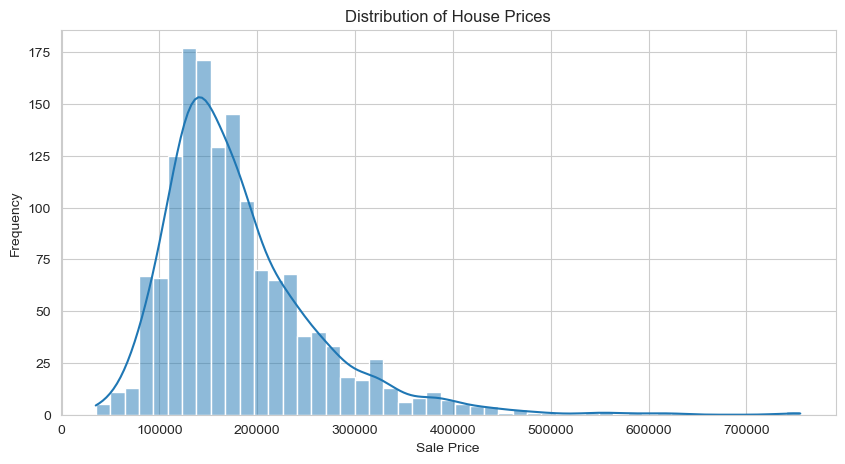

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df['SalePrice'], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

### Observation

The distribution of house prices is positively skewed, indicating that most houses are concentrated within a lower price range while a smaller number of houses have significantly higher prices.

## 8. Missing Value Analysis

Missing values can affect model performance and must be identified before model development. The following analysis highlights the features containing missing data.

In [14]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

### Observation

Several features contain missing values. Variables such as PoolQC, MiscFeature, Alley, and Fence have a substantial number of missing observations and may require special treatment during data cleaning.

## 9. Correlation Analysis

Correlation analysis is performed to identify the numerical features that have the strongest relationship with house prices. Features with high correlation are likely to be important predictors in the regression model.

In [12]:
corr_matrix = df.corr(numeric_only=True)

saleprice_corr = corr_matrix['SalePrice'].sort_values(ascending=False)

saleprice_corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

## 10. Identifying Key Predictors

The top features most strongly correlated with house prices are extracted for further analysis and model development.

In [13]:
top_corr = saleprice_corr[1:11]

top_corr

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

### Key Findings

Correlation analysis revealed that OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, and YearBuilt exhibit strong positive relationships with house prices.

These findings suggest that property size, construction quality, garage capacity, basement area, and property age are important factors influencing housing prices. The identified features will be further evaluated during model development to assess their predictive power.

## 11. Data Cleaning

Before building a predictive model, missing values must be handled appropriately. Features with a very high percentage of missing values provide limited information and may negatively impact model performance. Therefore, columns with excessive missing values will be removed.

In [21]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False).head(10)

PoolQC         99.520548
MiscFeature    96.301370
Alley          93.767123
Fence          80.753425
MasVnrType     59.726027
FireplaceQu    47.260274
LotFrontage    17.739726
GarageYrBlt     5.547945
GarageCond      5.547945
GarageType      5.547945
dtype: float64

### Observation

Several variables contain a substantial proportion of missing values. Features such as PoolQC, MiscFeature, Alley, Fence, and FireplaceQu have a high percentage of missing data and require special handling.

## 12. Removing Highly Incomplete Features

Features with more than 50% missing values are removed from the dataset because they provide insufficient information for reliable analysis and prediction.

In [22]:
columns_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

df = df.drop(columns=columns_to_drop)

print(df.shape)

(1460, 77)


### Observation

Columns with extremely high missing value percentages were removed to simplify preprocessing and improve data quality.

## 13. Handling Remaining Missing Values

The remaining missing values are imputed using appropriate statistical methods. Numerical variables are filled using the median, while categorical variables are filled using the mode.

In [24]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [25]:
df.isnull().sum().sum()

0

### Observation

All missing values have been successfully handled, resulting in a complete dataset ready for machine learning model development.

## 14. Relationship Between Living Area and House Price

A scatter plot is used to examine the relationship between above-ground living area and house price.

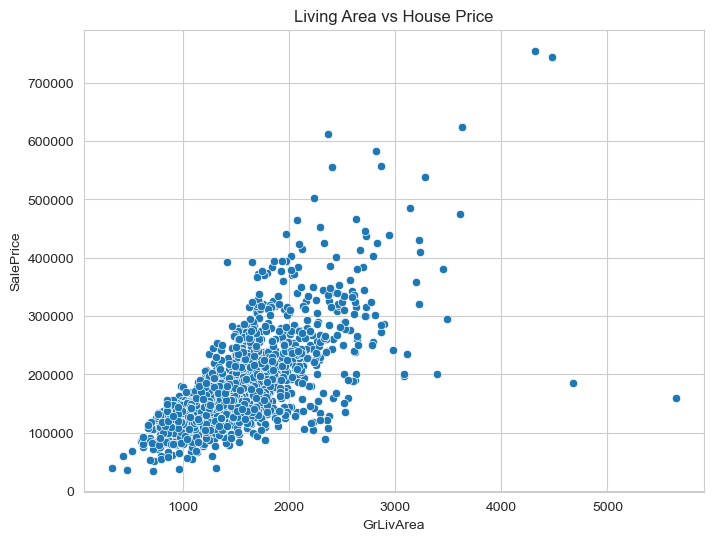

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='GrLivArea',
    y='SalePrice',
    data=df
)

plt.title("Living Area vs House Price")

plt.show()

### Observation

The scatter plot shows a strong positive relationship between living area (GrLivArea) and house price. As the living area increases, house prices generally tend to increase as well.

A few extreme observations can be seen at very large living areas, indicating the presence of potential outliers that may influence the regression model.

## 15. Correlation Heatmap

A correlation heatmap is generated to visualize the relationships among numerical variables and identify strong predictors of house prices.

In [27]:
top_features = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(10)

top_features

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

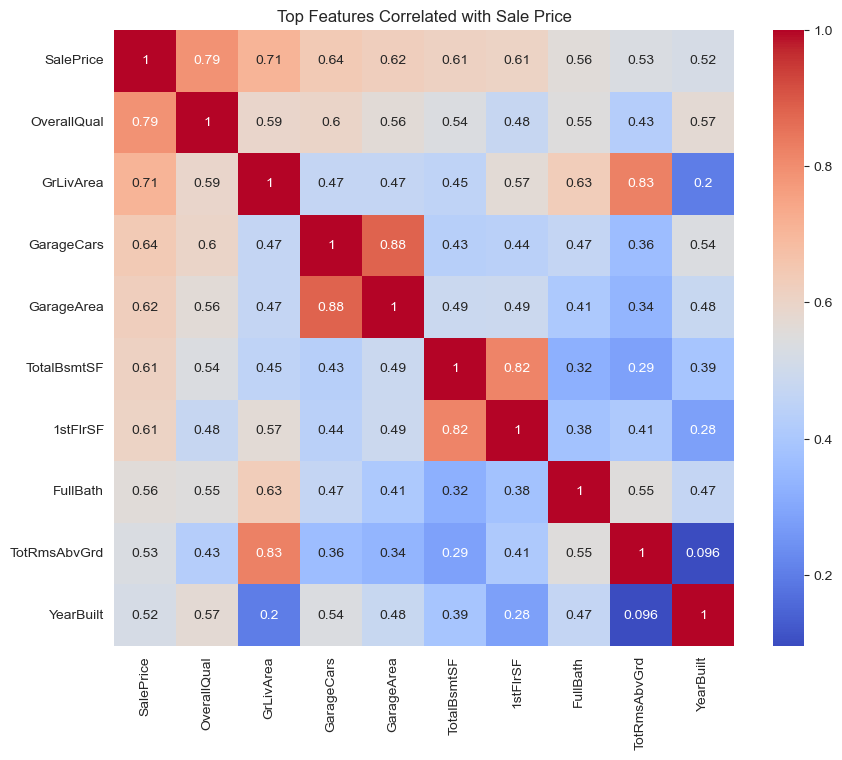

In [28]:
selected_features = top_features.index

plt.figure(figsize=(10,8))

sns.heatmap(
    df[selected_features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Top Features Correlated with Sale Price")

plt.show()

### Observation

The correlation heatmap confirms that OverallQual exhibits the strongest relationship with house prices, followed by GrLivArea, GarageCars, GarageArea, TotalBsmtSF, and YearBuilt.

These variables are likely to play an important role in predicting house prices and will be considered during model development.

## 16. Feature Selection

Based on the correlation analysis, the most influential numerical features are selected for the initial Linear Regression model. Selecting relevant predictors helps improve model performance and interpretability.

In [29]:
features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    'YearBuilt'
]

X = df[features]

y = df['SalePrice']

### Observation

Six highly correlated features were selected as predictor variables, while SalePrice was chosen as the target variable for prediction.

## 17. Splitting the Dataset

The dataset is divided into training and testing sets. The training set is used to build the model, while the testing set is used to evaluate its predictive performance on unseen data.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1168, 6)
Testing Set: (292, 6)


### Observation

Eighty percent of the data was allocated for model training and twenty percent for model testing to ensure reliable model evaluation.

## 18. Model Development

A Linear Regression model is developed to estimate house prices using the selected predictor variables.

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

### Observation

The Linear Regression model has been successfully trained using the selected housing features.

## 19. House Price Prediction

The trained model is used to predict house prices for the testing dataset.

In [32]:
y_pred = model.predict(X_test)

y_pred[:10]

array([141786.55124198, 296375.89118246, 119552.32280157, 178064.48889245,
       290810.46962353,  56415.71484826, 205192.28011414, 174520.8664729 ,
        55781.65421814, 129216.80394313])

### Observation

The model generated predicted house prices for unseen observations, which will be compared with actual prices to evaluate performance.

## 20. Model Evaluation

The model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²).

In [33]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 25171.740886907664
MSE: 1575542731.2079103
RMSE: 39693.10684751082
R² Score: 0.794592473820524


### Observation

The Linear Regression model achieved an R² score of approximately 0.79, indicating that nearly 79.5% of the variation in house prices can be explained by the selected predictor variables.

The model demonstrates strong predictive performance and confirms that factors such as house quality, living area, garage capacity, basement area, and construction year significantly influence housing prices.

## 21. Actual vs Predicted House Prices

To assess model performance visually, actual house prices are compared against predicted prices. A strong model should produce points close to the diagonal line.

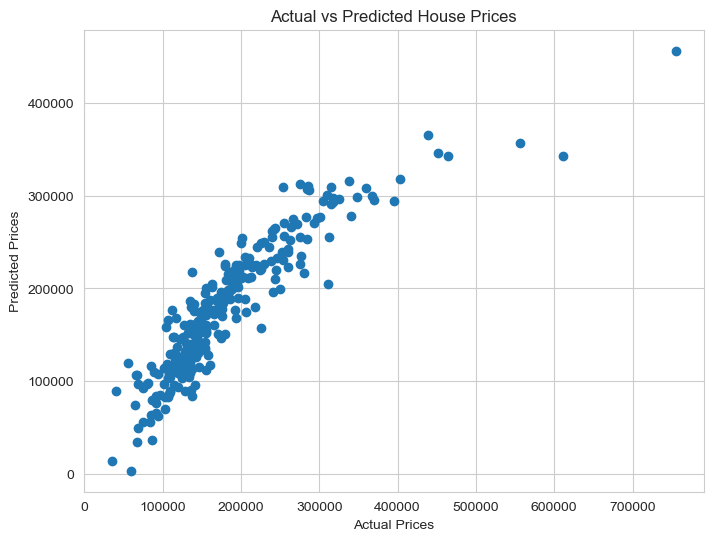

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

### Observation

Most observations are concentrated around the diagonal trend, indicating that the model predicts house prices reasonably well. Some deviations are present, particularly for higher-priced properties, suggesting opportunities for further model improvement.

## 22. Feature Contribution Analysis

The regression coefficients provide insight into how each feature influences the predicted house price.

In [35]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
0,OverallQual,20455.392441
2,GarageCars,11201.942630
5,YearBuilt,317.030315
1,GrLivArea,48.436190
4,TotalBsmtSF,24.382063
3,GarageArea,16.804641


### Observation

The coefficient analysis highlights the variables that contribute most strongly to house price predictions. Positive coefficients indicate that increases in these features are associated with higher property values.

# 23. Conclusion

This project developed a Linear Regression model to predict house prices using housing characteristics such as quality, living area, garage capacity, basement area, and construction year.

Key findings include:

- Overall quality is the strongest predictor of house prices.
- Larger living areas are associated with higher market values.
- Garage capacity and basement size positively influence house prices.
- Newer properties generally command higher prices.
- The developed model achieved an R² score of approximately 79.5%, demonstrating strong predictive capability.

The results indicate that property characteristics can effectively explain housing prices and provide valuable insights for buyers, sellers, and real estate professionals.

## Future Improvements

Several enhancements can be explored in future work:

- Include additional categorical variables through encoding techniques.
- Apply feature engineering to create new predictive variables.
- Evaluate advanced models such as Random Forest, XGBoost, and Gradient Boosting.
- Perform hyperparameter tuning to improve prediction accuracy.
- Implement cross-validation for more robust model evaluation.